This project explores a movie dataset using Python and Pandas.
The goal is to clean the data, perform exploratory data analysis (EDA), and discover meaningful insights about movie genres, ratings, popularity, languages, and release years.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Load Dataset

In [23]:
movies=pd.read_csv('mymoviedb (1).csv',engine="python")

# 2.Data Overview

## Question
What is the structure of the dataset?

In [6]:
# Display the dataset dimensions
movies.shape

(9837, 9)

In [21]:
movies.columns

Index(['Release_Date', 'Title', 'Overview', 'Popularity', 'Vote_Count',
       'Vote_Average', 'Original_Language', 'Genre', 'Poster_Url'],
      dtype='object')

In [8]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9837 entries, 0 to 9836
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9837 non-null   object 
 1   Title              9828 non-null   object 
 2   Overview           9828 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   object 
 5   Vote_Average       9827 non-null   object 
 6   Original_Language  9827 non-null   object 
 7   Genre              9826 non-null   object 
 8   Poster_Url         9826 non-null   object 
dtypes: float64(1), object(8)
memory usage: 691.8+ KB


In [24]:
# Display the first five rows of the dataset
movies.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [81]:
# Display the last five rows of the dataset
movies.tail()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url,Year
9832,1973-10-15,Badlands,A dramatization of the Starkweather-Fugate kil...,13.357,896,7.6,en,"[Drama, Crime]",https://image.tmdb.org/t/p/original/z81rBzHNgi...,1973
9833,2020-10-01,Violent Delights,A female vampire falls in love with a man she ...,13.356,8,3.5,es,[Horror],https://image.tmdb.org/t/p/original/4b6HY7rud6...,2020
9834,2016-05-06,The Offering,When young and successful reporter Jamie finds...,13.355,94,5.0,en,"[Mystery, Thriller, Horror]",https://image.tmdb.org/t/p/original/h4uMM1wOhz...,2016
9835,2021-03-31,The United States vs. Billie Holiday,Billie Holiday spent much of her career being ...,13.354,152,6.7,en,"[Music, Drama, History]",https://image.tmdb.org/t/p/original/vEzkxuE2sJ...,2021
9836,1984-09-23,Threads,Documentary style account of a nuclear holocau...,13.354,186,7.8,en,"[War, Drama, Science Fiction]",https://image.tmdb.org/t/p/original/lBhU4U9Eeh...,1984


In [24]:
#Display 10 random rows of the dataset
movies.sample(10)

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
5851,2016-12-16,The Lighthouse of the Orcas,A mother travels to Patagonia with her autisti...,18.838,179,7.0,es,"Drama, Romance",https://image.tmdb.org/t/p/original/7e47Dk3Qse...
6036,1990-02-16,Revenge,Michael ‘Jay’ Cochran has just left the Navy a...,18.479,337,6.6,en,"Romance, Thriller, Drama",https://image.tmdb.org/t/p/original/83diOZcg6Z...
8522,2016-12-16,A Kind of Murder,"In 1960s New York, Walter Stackhouse is a succ...",14.631,189,5.3,en,"Drama, Thriller",https://image.tmdb.org/t/p/original/hEeuCjUnGF...
3075,2020-07-10,The Old Guard,Four undying warriors who've secretly protecte...,29.640,3242,7.2,en,"Action, Fantasy",https://image.tmdb.org/t/p/original/cjr4NWURcV...
7078,2021-07-08,La civil,Cielo is a mother whose teenage daughter is ki...,16.598,3,4.3,es,"Drama, Crime",https://image.tmdb.org/t/p/original/bDxPuS199k...
4328,1997-07-03,Bean,"Childlike Englishman, Mr. Bean, is an incompet...",23.213,1937,6.4,en,"Comedy, Family, Adventure",https://image.tmdb.org/t/p/original/IwrDPrB4d2...
3701,2020-07-24,Amulet,"Tomaz, an ex-soldier now homeless in London, i...",25.931,85,5.5,en,Horror,https://image.tmdb.org/t/p/original/kEVyAkEkpw...
4152,1954-09-01,Rear Window,A wheelchair-bound photographer spies on his n...,23.872,5001,8.4,en,"Thriller, Mystery",https://image.tmdb.org/t/p/original/qitnZcLP7C...
6399,2011-09-24,The Ides of March,Dirty tricks stand to soil an ambitious young ...,17.763,1988,6.7,en,Drama,https://image.tmdb.org/t/p/original/w8t4UnJnC2...
2655,2013-04-03,App,A young psychology student is drawn into the d...,33.287,57,5.1,nl,Thriller,https://image.tmdb.org/t/p/original/mlJTIFUbTB...


# 3. Data Cleaning

### Question
How can we prepare the dataset for analysis?

In [13]:
# Check missing values
movies.isnull().sum() 

Release_Date            0
Title                   9
Overview                9
Popularity             10
Vote_Count             10
Vote_Average           10
Original_Language      10
Genre                9837
Poster_Url             11
dtype: int64

In [14]:
# Remove rows with missing values
movies = movies.dropna()

In [15]:
# Check that missing values have been removed
movies.isnull().sum()

Release_Date         0.0
Title                0.0
Overview             0.0
Popularity           0.0
Vote_Count           0.0
Vote_Average         0.0
Original_Language    0.0
Genre                0.0
Poster_Url           0.0
dtype: float64

In [16]:
# Check the number of rows and columns
movies.shape

(0, 9)

In [17]:
# Check for duplicate rows
movies.duplicated().sum()

0

In [18]:
movies["Vote_Count"].head()

Series([], Name: Vote_Count, dtype: object)

In [19]:
movies["Vote_Average"].head()

Series([], Name: Vote_Average, dtype: object)

In [25]:
movies["Vote_Count"].sample(10)

2782    2007
508      464
6317     521
2031      35
3630     217
1997     987
177      127
5514     301
4537    2656
6719      34
Name: Vote_Count, dtype: object

In [26]:
movies["Vote_Average"].sample(10)

2495    5.6
5625    5.7
5824    4.8
475     7.9
7574    7.3
2759    7.1
1923    5.0
8917    6.3
3674    7.8
2299    6.0
Name: Vote_Average, dtype: object

In [27]:
# Check the data type of each value in the column
movies["Vote_Count"].apply(type).value_counts()

<class 'str'>         9827
<class 'NoneType'>      10
Name: Vote_Count, dtype: int64

In [28]:
movies["Vote_Average"].apply(type).value_counts()

<class 'str'>         9827
<class 'NoneType'>      10
Name: Vote_Average, dtype: int64

In [31]:
# Convert data type from object to integer
movies["Vote_Count"] = pd.to_numeric(movies["Vote_Count"])

In [32]:
movies = movies.dropna().copy()

In [33]:
movies["Vote_Average"] = pd.to_numeric(movies["Vote_Average"])

In [34]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 9826 entries, 0 to 9836
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9826 non-null   object 
 1   Title              9826 non-null   object 
 2   Overview           9826 non-null   object 
 3   Popularity         9826 non-null   float64
 4   Vote_Count         9826 non-null   int64  
 5   Vote_Average       9826 non-null   float64
 6   Original_Language  9826 non-null   object 
 7   Genre              9826 non-null   object 
 8   Poster_Url         9826 non-null   object 
dtypes: float64(2), int64(1), object(6)
memory usage: 767.7+ KB


In [35]:
# Convert Release_Date to datetime format
movies["Release_Date"] = pd.to_datetime(movies["Release_Date"])

In [36]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 9826 entries, 0 to 9836
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Release_Date       9826 non-null   datetime64[ns]
 1   Title              9826 non-null   object        
 2   Overview           9826 non-null   object        
 3   Popularity         9826 non-null   float64       
 4   Vote_Count         9826 non-null   int64         
 5   Vote_Average       9826 non-null   float64       
 6   Original_Language  9826 non-null   object        
 7   Genre              9826 non-null   object        
 8   Poster_Url         9826 non-null   object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(5)
memory usage: 767.7+ KB


In [37]:
# Create a new column for the release year
movies["Year"] = movies["Release_Date"].dt.year

In [38]:
movies[["Release_Date","Year"]].head()

,Release_Date,Year
0,2021-12-15,2021
1,2022-03-01,2022
2,2022-02-25,2022
3,2021-11-24,2021
4,2021-12-22,2021


# 4.Exploratory Data Analysis (EDA)

## Original Language Analysis

### Question
Which languages are the most common in the dataset?

In [39]:
movies["Original_Language"].value_counts().head(10)

en    7569
ja     645
es     339
fr     292
ko     170
zh     129
it     123
cn     109
ru      83
de      82
Name: Original_Language, dtype: int64

In [40]:
movies["Original_Language"].value_counts().idxmax()

'en'

english is the most common

## Genre Analysis

### Question

Which movie genres are the most common?

In [41]:
movies["Genre"].head(10)

0    Action, Adventure, Science Fiction
1              Crime, Mystery, Thriller
2                              Thriller
3    Animation, Comedy, Family, Fantasy
4      Action, Adventure, Thriller, War
5               Action, Crime, Thriller
6             Horror, Mystery, Thriller
7                              Thriller
8                Action, Crime, Fantasy
9                       Science Fiction
Name: Genre, dtype: object

In [42]:
# Prepare the Genre column for analysis
movies["Genre"] = movies["Genre"].str.split(",")
movies_exploded = movies.explode("Genre")
movies_exploded["Genre"] = movies_exploded["Genre"].str.strip()



In [43]:
genre_count = movies_exploded["Genre"].value_counts()
genre_count

Drama              3744
Comedy             3031
Action             2686
Thriller           2488
Adventure          1853
Romance            1476
Horror             1470
Animation          1438
Family             1414
Fantasy            1308
Science Fiction    1273
Crime              1242
Mystery             773
History             427
War                 308
Music               295
Documentary         215
TV Movie            214
Western             137
Name: Genre, dtype: int64

Drama is the most common genre in the dataset.

## Question:

How are movie ratings distributed?

In [45]:
movies["Vote_Average"].describe()

count    9826.000000
mean        6.439467
std         1.129797
min         0.000000
25%         5.900000
50%         6.500000
75%         7.100000
max        10.000000
Name: Vote_Average, dtype: float64

In [46]:
movies[movies["Vote_Average"] == 10].shape[0]

1

In [47]:
movies[movies["Vote_Average"] == 0].shape[0]

100

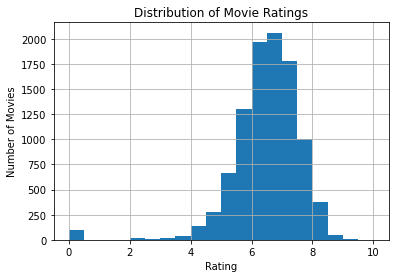

In [48]:
# Visualize the distribution of movie ratings
movies["Vote_Average"].hist(bins=20)
plt.title("Distribution of Movie Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Movies")
plt.savefig("images/genre_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

Most movies have ratings between 6 and 7.

In [49]:
movies["Vote_Count"].describe()

count     9826.000000
mean      1392.943721
std       2611.303856
min          0.000000
25%        146.000000
50%        444.000000
75%       1376.000000
max      31077.000000
Name: Vote_Count, dtype: float64

In [50]:
movies.loc[movies["Vote_Count"]>=500,['Title','Vote_Count','Vote_Average']].sort_values('Vote_Average',ascending=False).head(10)

,Title,Vote_Count,Vote_Average
657,The Shawshank Redemption,20911,8.7
609,The Godfather,15614,8.7
3156,Dilwale Dulhania Le Jayenge,3474,8.7
4196,Gabriel's Inferno Part III,946,8.6
1327,Schindler's List,12474,8.6
1007,The Godfather: Part II,9393,8.6
1769,GoodFellas,9860,8.5
419,The Lord of the Rings: The Return of the King,19183,8.5
3397,Wolfwalkers,714,8.5
3631,Seven Samurai,2580,8.5


## Question:

How is movie popularity distributed?

In [51]:
movies["Popularity"].describe()

count    9826.000000
mean       40.323951
std       108.879332
min        13.354000
25%        16.128250
50%        21.195000
75%        35.179250
max      5083.954000
Name: Popularity, dtype: float64

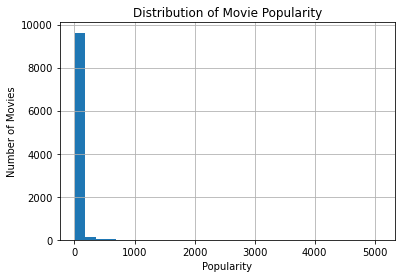

In [52]:
movies["Popularity"].hist(bins=30)
plt.title("Distribution of Movie Popularity")
plt.xlabel("Popularity")
plt.ylabel("Number of Movies")
plt.show()

Movie popularity is highly right-skewed.
Most movies have relatively low popularity, while only a few movies are extremely popular.

## Question:
Is there a relationship between popularity and movie ratings?

In [53]:
# Explore which movies have the highest popularity scores
movies[['Title','Vote_Count','Vote_Average','Popularity']].sort_values('Popularity',ascending=False).head(10)

,Title,Vote_Count,Vote_Average,Popularity
0,Spider-Man: No Way Home,8940,8.3,5083.954
1,The Batman,1151,8.1,3827.658
2,No Exit,122,6.3,2618.087
3,Encanto,5076,7.7,2402.201
4,The King's Man,1793,7.0,1895.511
5,The Commando,33,6.6,1750.484
6,Scream,821,6.8,1675.161
7,Kimi,206,6.3,1601.782
8,Fistful of Vengeance,114,5.3,1594.013
9,Eternals,4726,7.2,1537.406


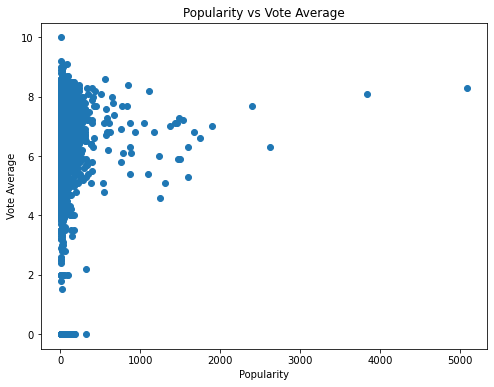

In [54]:
plt.figure(figsize=(8,6))
plt.scatter(movies["Popularity"], movies["Vote_Average"])
plt.title("Popularity vs Vote Average")
plt.xlabel("Popularity")
plt.ylabel("Vote Average")

plt.show()

In [55]:
movies["Popularity"].corr(movies["Vote_Average"])

0.05383355102241948

The correlation coefficient is approximately 0.05, indicating almost no linear relationship between popularity and average rating.

## Question:
How has movie production changed over time?

In [56]:
movies['Year'].value_counts().sort_index()

1902      1
1920      1
1921      2
1922      2
1925      1
       ... 
2020    453
2021    714
2022    208
2023      8
2024      1
Name: Year, Length: 102, dtype: int64

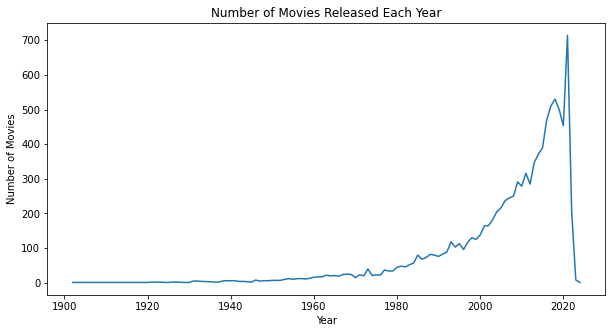

In [69]:
movies["Year"].value_counts().sort_index().plot(kind="line", figsize=(10,5))
plt.title("Number of Movies Released Each Year")
plt.xlabel("Year")
plt.ylabel("Number of Movies")

plt.show()

The number of released movies generally increased over time.
The sharp decline after 2021 is likely caused by incomplete data.

In [58]:
movies["Year"].max()

2024

In [59]:
movies["Year"].value_counts().sort_index().tail()

2020    453
2021    714
2022    208
2023      8
2024      1
Name: Year, dtype: int64

### Question
Which movie genres have the highest average ratings?

In [60]:
 #Calculate the average rating for each genre
genre_rating = movies_exploded.groupby("Genre")["Vote_Average"].mean()
genre_rating

Genre
Action             6.330268
Adventure          6.456719
Animation          6.846384
Comedy             6.382976
Crime              6.552013
Documentary        6.663721
Drama              6.706143
Family             6.581047
Fantasy            6.526300
History            6.965574
Horror             5.940068
Music              6.879322
Mystery            6.434282
Romance            6.560772
Science Fiction    6.257423
TV Movie           6.438318
Thriller           6.246141
War                6.948701
Western            6.754745
Name: Vote_Average, dtype: float64

In [66]:
genre_rating.idxmax()

'History'

show that history is the highest

In [63]:
genre_analysis = pd.DataFrame({
    "Average_Rating": genre_rating,
    "Movie_Count": genre_count
})
genre_analysis.sort_values("Average_Rating",ascending=False).head(10)

,Average_Rating,Movie_Count
History,6.965574,427
War,6.948701,308
Music,6.879322,295
Animation,6.846384,1438
Western,6.754745,137
Drama,6.706143,3744
Documentary,6.663721,215
Family,6.581047,1414
Romance,6.560772,1476
Crime,6.552013,1242


### Question

Which movie genres receive the highest average vote counts?

In [65]:
genre_votes = movies_exploded.groupby("Genre")["Vote_Count"].mean()
genre_votes

Genre
Action             1812.611690
Adventure          2328.045872
Animation          1060.507650
Comedy             1297.755526
Crime              1594.413043
Documentary         177.786047
Drama              1373.262553
Family             1447.400990
Fantasy            1928.088685
History            1234.323185
Horror              985.364626
Music              1008.291525
Mystery            1528.169470
Romance            1222.056911
Science Fiction    2239.179890
TV Movie            319.817757
Thriller           1459.643891
War                1457.525974
Western            1363.941606
Name: Vote_Count, dtype: float64

In [67]:
genre_votes.idxmax()

'Adventure'

show that Adventure is the highest